In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.optimize import minimize_scalar
#2nd variant

# ОМП

1) Сгенерировать выборку указанного вида при некотором θ, построить по ней график функции
g(θ) = n−1*ln L(θ) (в пункте б) – обычного) для следующих моделей при n = 1, 5, 20, 100. Отметить
на графике настоящее значение параметра и ОМП. Что такое информация Фишера с точки зрения
предельного поведения g(θ)?

(a) 1 вариант – X1, . . . , Xn ∼ N (0, θ), 2 вариант X1, . . . , Xn ∼ N (θ, 1).

(b) X1, . . . , Xn ∼ R[0, θ].

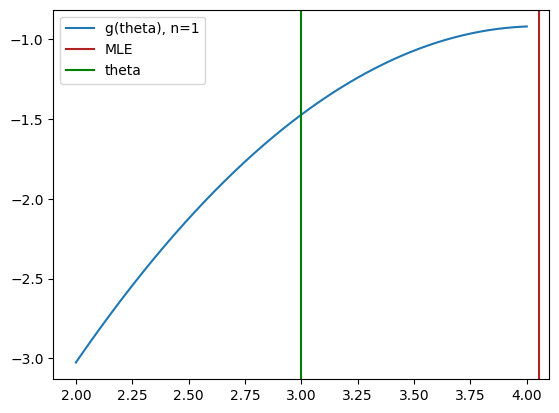

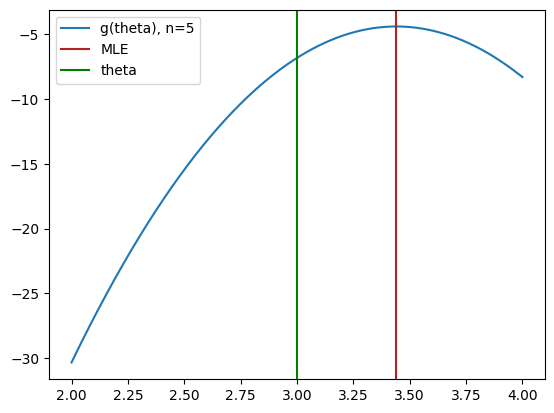

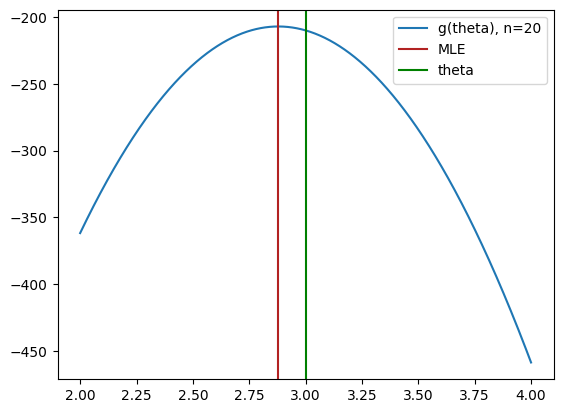

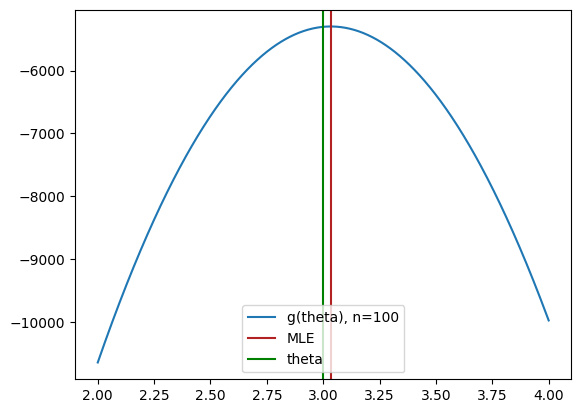

In [ ]:
n_vals = [1,5, 20, 100]
theta = 3
for n in n_vals:
  x_data = np.random.normal(theta, 1, size = n)
  x = np.linspace(theta - 1, theta+1, 1000)
  plt.plot(x, -0.5*np.log(2*np.pi)-0.5*n*sum([(i-x)**2 for i in x_data]), label = f'g(theta), n={n}')
  plt.axvline(x = np.mean(x_data), color = 'firebrick' ,label='MLE')
  plt.axvline(theta, color = 'green', label = 'theta')
  plt.legend()
  plt.show()


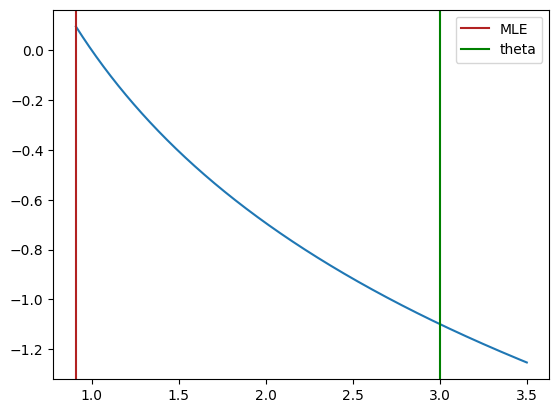

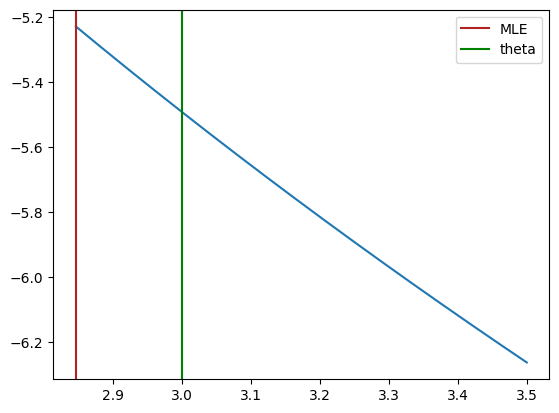

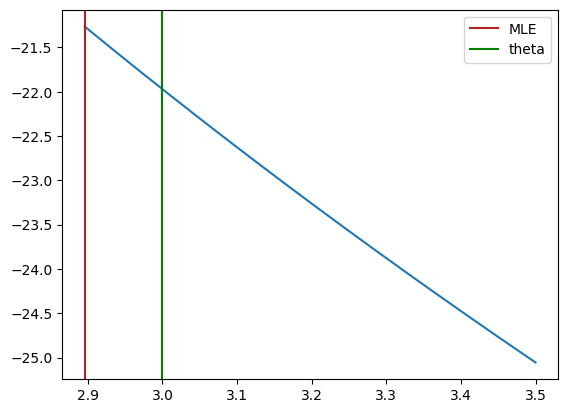

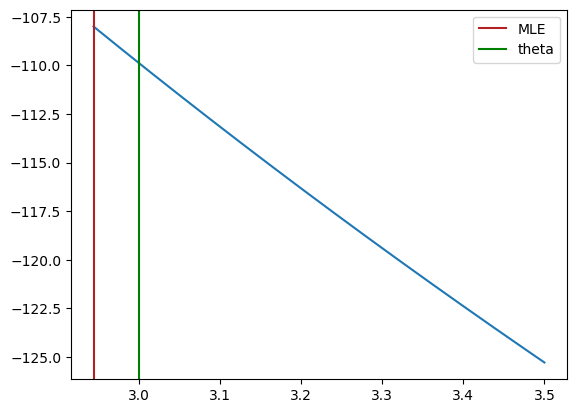

In [ ]:
n_vals = [1,5, 20, 100]
theta = 3
for n in n_vals:
  x_data = np.random.uniform(0, theta, size = n)
  x = np.linspace(max(x_data), theta+0.5, 1000)
  plt.plot(x, -n*np.log(x))
  plt.axvline(x = max(x_data), color = 'firebrick' ,label='MLE')
  plt.axvline(theta, color = 'green', label = 'theta')
  plt.legend()
  plt.show()

2*) Пусть X1, . . . , Xn выборки из распределения, являющегося смесью N(θ1, θ2) и N(0, 1) c весами 1/2,
1/2; здесь требуется построить графики L(θ2) при фиксированном значении первого параметра:

а) θ1 – настоящее значение (с которым генерировалась выборка),

б) θ1 = X1. Во втором случае
рассмотреть близкие к нулю значения θ2 при больших n.

/tmp/ipython-input-2091072370.py:13: RuntimeWarning: invalid value encountered in sqrt
  return 0.5 * norm.pdf(x, loc=theta1, scale=np.sqrt(theta2)) + 0.5 * norm.pdf(x, loc=0, scale=1)


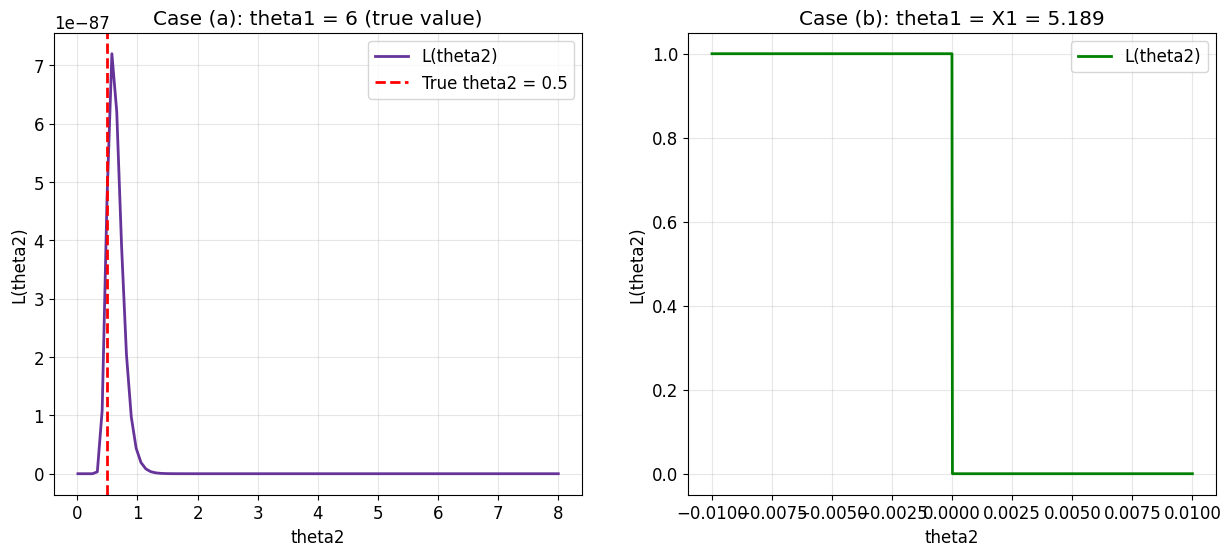

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

n = 100
true_theta1 = 6
true_theta2 = 0.5

def mixture_density(x, theta1, theta2):
    return 0.5 * norm.pdf(x, loc=theta1, scale=np.sqrt(theta2)) + 0.5 * norm.pdf(x, loc=0, scale=1)

def log_likelihood(theta2, sample, theta1):
    log_lik = 0
    for x in sample:
        density = mixture_density(x, theta1, theta2)
        if density > 0:
            log_lik += np.log(density)
    return log_lik

def generate_sample(n, theta1, theta2):
    sample = []
    for i in range(n):
        if np.random.random() < 0.5:
            x = np.random.normal(theta1, np.sqrt(theta2))
        else:
            x = np.random.normal(0, 1)
        sample.append(x)
    return np.array(sample)


#generate x data
sample = generate_sample(n, true_theta1, true_theta2)

theta1_a = true_theta1
theta1_b = sample[0]

theta2_range_a = np.linspace(0.01, 8, 100)
theta2_range_b = np.linspace(-0.01, 0.01, 1000)

likelihoods_a = [np.exp(log_likelihood(theta2, sample, theta1_a)) for theta2 in theta2_range_a]
likelihoods_b = [np.exp(log_likelihood(theta2, sample, theta1_b)) for theta2 in theta2_range_b]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(theta2_range_a, likelihoods_a, 'rebeccapurple', linewidth=2, label='L(theta2)')
ax1.axvline(x=true_theta2, color='r', linestyle='--', linewidth=2, label=f'True theta2 = {true_theta2}')
ax1.set_xlabel('theta2')
ax1.set_ylabel('L(theta2)')
ax1.set_title(f'Case (a): theta1 = {theta1_a} (true value)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(theta2_range_b, likelihoods_b, 'g-', linewidth=2, label='L(theta2)')
#ax2.axvline(x=true_theta2, color='r', linestyle='--', linewidth=2, label=f'True theta2 = {true_theta2}')
ax2.set_xlabel('theta2')
ax2.set_ylabel('L(theta2)')
ax2.set_title(f'Case (b): theta1 = X1 = {theta1_b:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()

3) Xi имеют распределение Коши, где в варианте 1 неизвестный параметр — сдвиг θ, а в варианте 2
– масштаб. Построить ОМП по выборке размера n = 5, 10, 20, 50, 100. Для каждого n генерировать
k = 500 выборок X1, . . . , Xn, для каждой найти значение ОМП и θb, найти выборочное среднее и
выборочную дисперсию ОМП и θb и сравнить их. Здесь θb для первого варианта – это выборочная
медиана, а для второго – половина интерквартильного размаха, то есть полуразность верхнего и
нижнего выборочного квартиля.

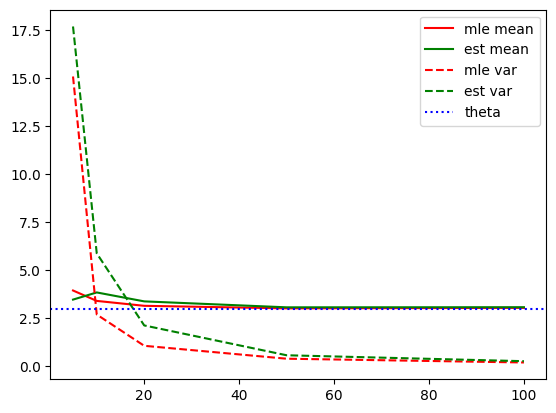

In [ ]:
def half_interq(data):
  data.sort()
  n = len(data)
  high = data[int(n*0.75)]
  low = data[int(n*0.25)]
  return (high - low)/2


def cauchy_mle(sample):
  sample = np.asarray(sample)
  n = len(sample)
  def negative_log_likelihood(theta):
    if theta <= 0:
      return np.inf
    return n * np.log(theta) + np.sum(np.log(1 + (sample / theta)**2))
  mad = np.median(np.abs(sample - np.median(sample)))
  initial_guess = mad / 0.6745
  result = minimize_scalar(negative_log_likelihood,
                           bounds=(1e-10, 10 * initial_guess),
                           method='bounded')
  return result.x

# как найти омп???

n_vals = [5, 10, 20, 50, 100]
theta = 3
k = 500

mle_mean = []
est_mean = []
mle_var = []
est_var = []

for n in n_vals:
  mle = []
  est = []
  for i in range(k):
    x_data = stats.cauchy.rvs(loc = 0, scale = theta,size = n)
    mle.append(cauchy_mle(x_data))
    est.append(half_interq(x_data))
  mle_mean.append(np.mean(mle))
  est_mean.append(np.mean(est))
  mle_var.append(np.var(mle))
  est_var.append(np.var(est))
plt.plot(n_vals, mle_mean, label = 'mle mean', color = 'r')
plt.plot(n_vals, est_mean, label = 'est mean', color='g')
plt.plot(n_vals, mle_var,'r--', label = 'mle var')
plt.plot(n_vals, est_var,'g--', label = 'est var' )
plt.axhline(y = theta, color = 'b',linestyle=':', label = 'theta')
plt.legend()

4) 1 вариант – X1, ..., Xn ∼ N (θ, 1), 2 вариант – X1, . . . , Xn ∼ N (0, θ), θb1 – ОММ, θb2 – ОМС, θb3 – ОМП.

(a) Построить по выборке θbi, i = 1, 2, 3 (найти численно или аналитически, как удобнее).

(b) Сравнить, какая из оценок чаще оказывается ближе к θ при разных n, смоделировав для
этого по 1000 реализаций (для каждого n).

(c) Построить гистограммы для √ n(θbi − θ) на одном графике, сравнить разбросы.

for n=5: MLE and MOM closer in 0.679 cases, MSE closer = 0.321


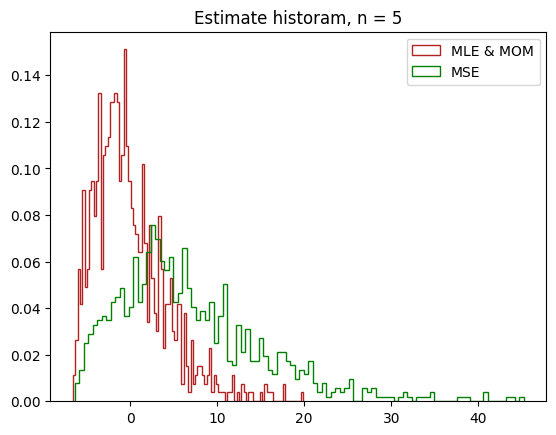

for n=10: MLE and MOM closer in 0.643 cases, MSE closer = 0.357


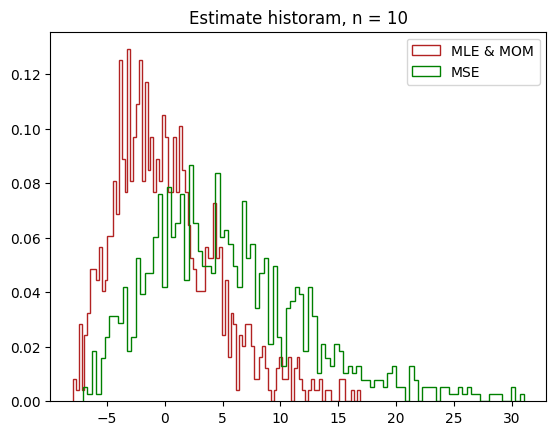

for n=100: MLE and MOM closer in 0.612 cases, MSE closer = 0.388


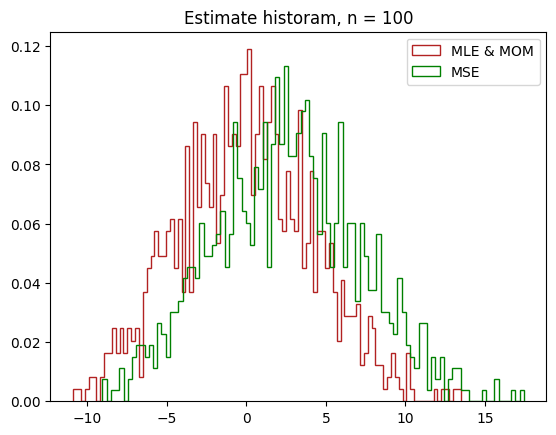

for n=1000: MLE and MOM closer in 0.534 cases, MSE closer = 0.466


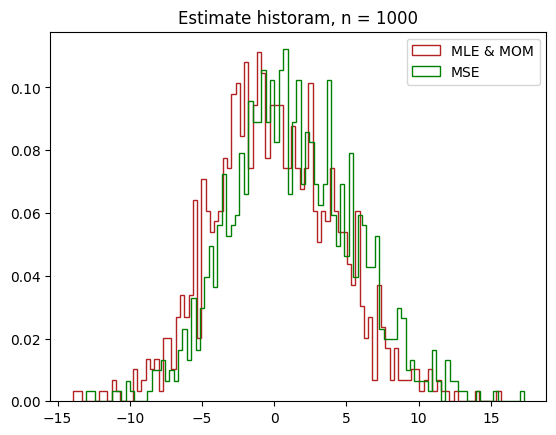

In [ ]:
n_val = [5, 10 ,100, 1000]
k = 1000
theta = 3

def mse_norm(sample):
  sample = np.asarray(sample)
  n = len(sample)
  sorted_sample = np.sort(sample)
  def d_func(theta):
    if theta <=0:
      return np.inf
    sigma = np.sqrt(theta)
    f_values = stats.norm.cdf(sorted_sample, scale = sigma)
    spacing = np.diff(f_values)
    spacing = np.concatenate([[f_values[0]], spacing, [1 - f_values[-1]]])
    spacing = spacing[spacing > 1e-10]
    log_sum =np.sum(np.log(spacing))
    return -log_sum
  result = minimize_scalar(d_func,
                           bounds=(1e-6, np.var(sample) * 10),
                           method='bounded')

  return result.x


for n in n_val:
  mle = []
  mom = []
  mse = []
  c1 = 0
  c2 = 0
  for i in range(k):
    x_data = stats.norm.rvs(0, np.sqrt(theta), size = n)
    e1 = np.mean(x_data**2)
    e2 = mse_norm(x_data)
    mle.append(e1)
    mom.append(e1)
    mse.append(e2)
    if np.abs(e1-theta) <= np.abs(e2-theta):
      c1+=1
    else:
      c2+=1
  print(f'for n={n}: MLE and MOM closer in {c1/k} cases, MSE closer = {c2/k}')
  mle_hist = [np.sqrt(n)*(i-theta) for i in mle]
  mse_hist = [np.sqrt(n)*(i-theta) for i in mse]
  plt.hist(mle_hist, bins = 100, density =True, color = 'firebrick', histtype = 'step', label = 'MLE & MOM')
  plt.hist(mse_hist, bins = 100, density =True, color = 'green', histtype = 'step', label = 'MSE')
  plt.title(f'Estimate historam, n = {n}')
  plt.legend()
  plt.show()

5*) 1-й вариант: X1, ..., Xn ∼ Beta(a, b), **2-й вариант**: X1, ..., Xn ∼ Gamma(a, b),
θ = (a, b), θb1 = (ba1,bb1) – ОМП, θb2 = (ba2,bb2) – ОМС.

(a) Построить по выборке оценки θb1 и θb2 (найти численно).

(b) Сравнить, какая из оценок чаще оказывается ближе к θ при разных n (отдельно по каждой
координате и в смысле расстояния на плоскости), смоделировав для этого по 1000 реализаций
(для каждого n).

(c) Построить гистограммы (одномерные) для √n(θbi − θ) на одном графике, сравнить разбросы.

MSE для a лучше в 0.414 случаев
MSE для b лучше в 0.411 случаев
MSE для пары (a, b) лучше в 0.409 случаев

MLE для a лучше в 0.586 случаев
MLE для b лучше в 0.589 случаев
MLE для пары (a, b) лучше в 0.591 случаев


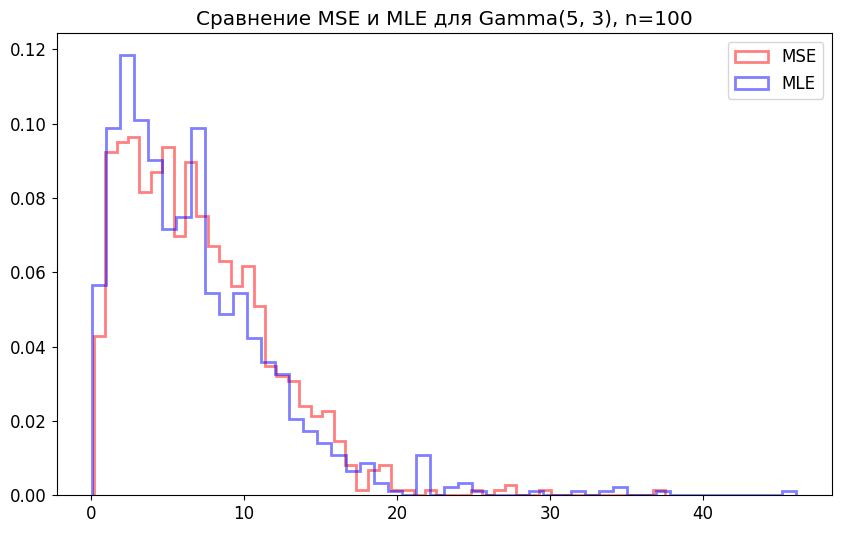

In [ ]:
import numpy as np
from scipy.special import digamma, gamma,gammaln
from scipy.optimize import minimize_scalar, minimize
import scipy.stats as stats
import matplotlib.pyplot as plt

# Параметры
n = 100
runs = 1000
a = 5
b = 3  # rate parameter (scale = 1/b)

# Списки для хранения результатов
a_mle = []
b_mle = []
a_mse = []
b_mse = []

dist_mse_all = []
dist_mle_all = []

# Счетчики для сравнения
mse_wins_a = 0
mle_wins_a = 0
mse_wins_b = 0
mle_wins_b = 0
mse_wins_pair = 0
mle_wins_pair = 0

# Функция для MLE Gamma-распределения
def neg_log_likelihood_gamma(params, sample):
    a, b = params
    if a <= 0 or b <= 0:
        return 1e10
    nll = len(sample) * (a * np.log(b) - np.log(gamma(a))) + (a - 1) * np.sum(np.log(sample)) - b * np.sum(sample)
    return nll

def mle_gamma(x_data):
    n_len = len(x_data)
    x_mean = np.mean(x_data)

    def neg_log_likelihood(params):
        a, b = params
        if a <= 0 or b <= 0:
            return 1e10
        return -(n_len * a * np.log(b) - n_len * gammaln(a) +
                 (a - 1) * np.sum(np.log(x_data)) - b * np.sum(x_data))

    # Начальные приближения
    var_val = np.var(x_data, ddof=1)
    if var_val > 0:
        a0 = x_mean**2 / var_val  # метод моментов
    else:
        a0 = 1.0
    b0 = a0 / x_mean

    bounds = [(0.01, 100), (0.01, 100)]
    result = minimize(neg_log_likelihood, [a0, b0], bounds=bounds, method='L-BFGS-B')

    return result.x[0], result.x[1]

def mse_gamma(sample):
    x = np.sort(sample)
    n = len(x)

    def objective(params):
        a, b = params
        if a <= 0 or b <= 0:
            return 1e10
        F = stats.gamma.cdf(x, a, scale=1/b)
        F_extended = np.concatenate([[0], F, [1]])
        spacings = np.diff(F_extended)

        spacings = np.clip(spacings, 1e-15, None)
        return -np.sum(np.log(spacings))

    mean_val = np.mean(sample)
    var_val = np.var(sample, ddof=1)

    if var_val > 0:
        a0 = mean_val**2 / var_val
        b0 = mean_val / var_val
    else:
        a0, b0 = 1.0, 1.0

    bounds = [(0.001, 100), (0.001, 100)]
    result = minimize(objective, [a0, b0], bounds=bounds, method='L-BFGS-B')
    return result.x


for _ in range(runs):
    x_data = stats.gamma.rvs(a, scale=1/b, size=n)

    a1, b1 = mle_gamma(x_data)
    a2, b2 = mse_gamma(x_data)

    a_mle.append(a1)
    b_mle.append(b1)
    a_mse.append(a2)
    b_mse.append(b2)

    dist_a_mse = abs(a2 - a)
    dist_b_mse = abs(b2 - b)
    dist_a_mle = abs(a1 - a)
    dist_b_mle = abs(b1 - b)
    dist_mse = np.sqrt(dist_a_mse**2 + dist_b_mse**2)
    dist_mle = np.sqrt(dist_a_mle**2 + dist_b_mle**2)


    dist_mse_all.append(np.sqrt(n) * dist_mse)
    dist_mle_all.append(np.sqrt(n) * dist_mle)

    if dist_a_mse < dist_a_mle:
        mse_wins_a += 1
    else:
        mle_wins_a += 1

    if dist_b_mse < dist_b_mle:
        mse_wins_b += 1
    else:
        mle_wins_b += 1

    if dist_mse < dist_mle:
        mse_wins_pair += 1
    else:
        mle_wins_pair += 1




print(f"MSE для a лучше в {mse_wins_a/runs:.3f} случаев")
print(f"MSE для b лучше в {mse_wins_b/runs:.3f} случаев")
print(f"MSE для пары (a, b) лучше в {mse_wins_pair/runs:.3f} случаев")
print()
print(f"MLE для a лучше в {mle_wins_a/runs:.3f} случаев")
print(f"MLE для b лучше в {mle_wins_b/runs:.3f} случаев")
print(f"MLE для пары (a, b) лучше в {mle_wins_pair/runs:.3f} случаев")

plt.figure(figsize=(10, 6))
plt.hist(dist_mse_all, bins=50, alpha=0.5, label='MSE', density=True, color='red', histtype='step', linewidth=2)
plt.hist(dist_mle_all, bins=50, alpha=0.5, label='MLE', density=True, color='blue', histtype='step', linewidth=2)
plt.title(f'Сравнение MSE и MLE для Gamma({a}, {b}), n={n}')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from scipy.special import digamma, gamma, gammaln
from scipy.optimize import root_scalar
import scipy.stats as stats
import matplotlib.pyplot as plt

# Параметры
n = 100
runs = 1000
a = 5
b = 3  # rate parameter

# Списки для хранения результатов
a_mle = []
b_mle = []
a_mse = []
b_mse = []

dist_mse_all = []
dist_mle_all = []

# Счетчики для сравнения
mse_wins_a = 0
mle_wins_a = 0
mse_wins_b = 0
mle_wins_b = 0
mse_wins_pair = 0
mle_wins_pair = 0

# Функция для MLE Gamma-распределения (аналитическое решение)
def mle_gamma(x_data):
    """Вычисление MLE для Gamma-распределения аналитически"""
    n_len = len(x_data)
    x_mean = np.mean(x_data)
    log_mean = np.log(x_mean)
    mean_log = np.mean(np.log(x_data))

    # Решаем уравнение: log(a) - digamma(a) = log(x_mean) - mean(log(x))
    diff = log_mean - mean_log

    # Функция для решения
    def equation(a):
        return np.log(a) - digamma(a) - diff

    # Ищем корень уравнения
    # Для Gamma a > 0, начнем с метода моментов
    var_val = np.var(x_data, ddof=1)
    if var_val > 0:
        a_mm = x_mean**2 / var_val  # метод моментов
    else:
        a_mm = 1.0

    # Ищем решение численно
    try:
        # Пробуем найти корень
        result = root_scalar(equation, bracket=[0.01, 100], method='brentq')
        a_est = result.root
    except:
        # Если не получается, используем приближение
        if diff > 0:
            # Приближение для малых a
            a_est = (1 + np.sqrt(1 + 4*diff/3)) / (2*diff)
        else:
            a_est = a_mm

    # b = a / x_mean
    b_est = a_est / x_mean

    return a_est, b_est

# Альтернативная реализация через численную оптимизацию (на всякий случай)
def mle_gamma_numerical(x_data):
    """Численная оптимизация для MLE"""
    n_len = len(x_data)
    x_mean = np.mean(x_data)

    def neg_log_likelihood(params):
        a, b = params
        if a <= 0 or b <= 0:
            return 1e10
        return -(n_len * a * np.log(b) - n_len * gammaln(a) +
                 (a - 1) * np.sum(np.log(x_data)) - b * np.sum(x_data))

    # Начальные приближения
    var_val = np.var(x_data, ddof=1)
    if var_val > 0:
        a0 = x_mean**2 / var_val  # метод моментов
    else:
        a0 = 1.0
    b0 = a0 / x_mean

    bounds = [(0.01, 100), (0.01, 100)]
    result = minimize(neg_log_likelihood, [a0, b0], bounds=bounds, method='L-BFGS-B')

    return result.x[0], result.x[1]

# Функция для MSE (Maximum Spacings Estimation) - упрощенная
def mse_gamma(sample):
    """Maximum Spacings Estimation для Gamma-распределения"""
    x = np.sort(sample)
    n_len = len(x)

    def objective(params):
        a, b = params
        if a <= 0 or b <= 0:
            return 1e10

        # CDF Gamma распределения
        try:
            F = stats.gamma.cdf(x, a, scale=1/b)  # scale = 1/b для rate parameter
        except:
            return 1e10

        F_extended = np.concatenate([[0], F, [1]])
        spacings = np.diff(F_extended)

        # Избегаем нулевых значений
        spacings = np.maximum(spacings, 1e-15)

        return -np.sum(np.log(spacings))

    # Начальные приближения (используем метод моментов)
    mean_val = np.mean(sample)
    var_val = np.var(sample, ddof=1)

    if var_val > 0:
        a0 = mean_val**2 / var_val
        b0 = mean_val / var_val
    else:
        a0, b0 = 1.0, 1.0

    bounds = [(0.01, 100), (0.01, 100)]
    result = minimize(objective, [a0, b0], bounds=bounds, method='L-BFGS-B',
                     options={'ftol': 1e-10, 'maxiter': 2000})

    return result.x[0], result.x[1]

# Основной цикл симуляции
print("Запуск симуляции...")
for i in range(runs):
    # Генерируем данные из Gamma распределения
    x_data = stats.gamma.rvs(a, scale=1/b, size=n)

    # Получаем оценки MLE (аналитически)
    try:
        a1, b1 = mle_gamma(x_data)
        # Проверяем на разумность
        if a1 > 100 or b1 > 100 or a1 < 0.01 or b1 < 0.01:
            a1, b1 = mle_gamma_numerical(x_data)
    except Exception as e:
        # Если аналитический метод не сработал
        a1, b1 = mle_gamma_numerical(x_data)

    # Получаем оценки MSE
    a2, b2 = mse_gamma(x_data)

    # Сохраняем оценки
    a_mle.append(a1)
    b_mle.append(b1)
    a_mse.append(a2)
    b_mse.append(b2)

    # Вычисляем расстояния
    dist_a_mse = abs(a2 - a)
    dist_b_mse = abs(b2 - b)
    dist_a_mle = abs(a1 - a)
    dist_b_mle = abs(b1 - b)

    # Евклидово расстояние
    dist_mse = np.sqrt(dist_a_mse**2 + dist_b_mse**2)
    dist_mle = np.sqrt(dist_a_mle**2 + dist_b_mle**2)

    # Сохраняем масштабированные расстояния
    dist_mse_all.append(np.sqrt(n) * dist_mse)
    dist_mle_all.append(np.sqrt(n) * dist_mle)

    # Сравниваем производительность
    if dist_a_mse < dist_a_mle:
        mse_wins_a += 1
    elif dist_a_mle < dist_a_mse:
        mle_wins_a += 1

    if dist_b_mse < dist_b_mle:
        mse_wins_b += 1
    elif dist_b_mle < dist_b_mse:
        mle_wins_b += 1

    if dist_mse < dist_mle:
        mse_wins_pair += 1
    elif dist_mle < dist_mse:
        mle_wins_pair += 1

    # Прогресс
    if (i + 1) % 100 == 0:
        print(f"  Завершено {i + 1}/{runs} итераций")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ MLE И MSE:")
print("="*60)
print(f"Размер выборки n = {n}")
print(f"Истинные параметры: a = {a}, b = {b}")
print()

print("ПО ПАРАМЕТРУ a:")
print(f"  MSE лучше в {mse_wins_a/runs:.3%} случаев")
print(f"  MLE лучше в {mle_wins_a/runs:.3%} случаев")
print(f"  Ничья в {(1 - (mse_wins_a + mle_wins_a)/runs):.3%} случаев")
print()

print("ПО ПАРАМЕТРУ b:")
print(f"  MSE лучше в {mse_wins_b/runs:.3%} случаев")
print(f"  MLE лучше в {mle_wins_b/runs:.3%} случаев")
print(f"  Ничья в {(1 - (mse_wins_b + mle_wins_b)/runs):.3%} случаев")
print()

print("ПО ПАРЕ (a,b) (евклидово расстояние):")
print(f"  MSE лучше в {mse_wins_pair/runs:.3%} случаев")
print(f"  MLE лучше в {mle_wins_pair/runs:.3%} случаев")
print(f"  Ничья в {(1 - (mse_wins_pair + mle_wins_pair)/runs):.3%} случаев")

# Построение гистограмм
plt.figure(figsize=(12, 10))

# Гистограмма для масштабированных расстояний
plt.subplot(2, 2, 1)
bins = np.linspace(0, max(max(dist_mse_all), max(dist_mle_all)) + 1, 50)
plt.hist(dist_mse_all, bins=bins, alpha=0.5, label='MSE', density=True,
         color='red', histtype='step', linewidth=2)
plt.hist(dist_mle_all, bins=bins, alpha=0.5, label='MLE', density=True,
         color='blue', histtype='step', linewidth=2)
plt.xlabel(r'$\sqrt{n} \cdot \|\hat{\theta} - \theta\|$')
plt.ylabel('Плотность')
plt.title(f'Масштабированные расстояния (n={n})')
plt.legend()
plt.grid(True, alpha=0.3)

# Гистограмма для ошибок параметра a
plt.subplot(2, 2, 2)
errors_a_mle = np.array(a_mle) - a
errors_a_mse = np.array(a_mse) - a
bin_width = 0.5 * min(np.std(errors_a_mle), np.std(errors_a_mse))
bins_a = np.arange(min(min(errors_a_mle), min(errors_a_mse)) - bin_width,
                   max(max(errors_a_mle), max(errors_a_mse)) + bin_width, bin_width/2)
plt.hist(errors_a_mle, bins=bins_a, alpha=0.5, label='MLE', density=True,
         color='blue', histtype='step', linewidth=2)
plt.hist(errors_a_mse, bins=bins_a, alpha=0.5, label='MSE', density=True,
         color='red', histtype='step', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(f'Ошибка оценки параметра a')
plt.ylabel('Плотность')
plt.title(f'Распределение ошибок для a (истинное = {a})')
plt.legend()
plt.grid(True, alpha=0.3)

# Гистограмма для ошибок параметра b
plt.subplot(2, 2, 3)
errors_b_mle = np.array(b_mle) - b
errors_b_mse = np.array(b_mse) - b
bin_width = 0.5 * min(np.std(errors_b_mle), np.std(errors_b_mse))
bins_b = np.arange(min(min(errors_b_mle), min(errors_b_mse)) - bin_width,
                   max(max(errors_b_mle), max(errors_b_mse)) + bin_width, bin_width/2)
plt.hist(errors_b_mle, bins=bins_b, alpha=0.5, label='MLE', density=True,
         color='blue', histtype='step', linewidth=2)
plt.hist(errors_b_mse, bins=bins_b, alpha=0.5, label='MSE', density=True,
         color='red', histtype='step', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(f'Ошибка оценки параметра b')
plt.ylabel('Плотность')
plt.title(f'Распределение ошибок для b (истинное = {b})')
plt.legend()
plt.grid(True, alpha=0.3)

# Диаграмма рассеяния оценок
plt.subplot(2, 2, 4)
plt.scatter(a_mle, b_mle, alpha=0.5, label='MLE', s=10, color='blue')
plt.scatter(a_mse, b_mse, alpha=0.5, label='MSE', s=10, color='red')
plt.scatter([a], [b], s=200, marker='*', color='gold', edgecolor='black',
           linewidth=2, label='Истинные значения', zorder=5)
plt.xlabel('Параметр a')
plt.ylabel('Параметр b')
plt.title(f'Оценки параметров (n={n})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*60)
print("СТАТИСТИКА ОЦЕНОК:")
print("="*60)
print(f"Истинные значения: a = {a}, b = {b}")

print("\nMLE ОЦЕНКИ:")
print(f"  Среднее a: {np.mean(a_mle):.4f} ± {np.std(a_mle):.4f}")
print(f"  Смещение a: {np.mean(a_mle) - a:.4f}")
print(f"  MSE a: {np.mean((np.array(a_mle) - a)**2):.6f}")
print(f"  Среднее b: {np.mean(b_mle):.4f} ± {np.std(b_mle):.4f}")
print(f"  Смещение b: {np.mean(b_mle) - b:.4f}")
print(f"  MSE b: {np.mean((np.array(b_mle) - b)**2):.6f}")
print(f"  Среднее расстояние: {np.mean(dist_mle):.4f}")

print("\nMSE ОЦЕНКИ (Maximum Spacings):")
print(f"  Среднее a: {np.mean(a_mse):.4f} ± {np.std(a_mse):.4f}")
print(f"  Смещение a: {np.mean(a_mse) - a:.4f}")
print(f"  MSE a: {np.mean((np.array(a_mse) - a)**2):.6f}")
print(f"  Среднее b: {np.mean(b_mse):.4f} ± {np.std(b_mse):.4f}")
print(f"  Смещение b: {np.mean(b_mse) - b:.4f}")
print(f"  MSE b: {np.mean((np.array(b_mse) - b)**2):.6f}")
print(f"  Среднее расстояние: {np.mean(dist_mse):.4f}")

print("\nОТНОШЕНИЕ MSE (среднеквадратичных ошибок):")
mse_a_ratio = np.mean((np.array(a_mse) - a)**2) / np.mean((np.array(a_mle) - a)**2)
mse_b_ratio = np.mean((np.array(b_mse) - b)**2) / np.mean((np.array(b_mle) - b)**2)
print(f"  Для a: MSE(MSE_estimator)/MSE(MLE) = {mse_a_ratio:.4f}")
print(f"  Для b: MSE(MSE_estimator)/MSE(MLE) = {mse_b_ratio:.4f}")